# 08 Classification Modeling

## Objective

In this notebook, I test whether the stylometric features extracted from LLM-generated texts can predict the model family that produced each text.

The previous statistical-testing notebook showed that 41 out of 43 stylometric features differ significantly across model families after FDR correction. However, statistical significance only tells me that the model families differ; it does not tell me whether those differences are strong enough to identify the generating model in a predictive setting.

This notebook therefore moves from formal statistical comparison to supervised classification.

## Research Question

Can stylometric features distinguish texts generated by different LLMs?

## Classification Question

Given only stylometric features extracted from a generated text, can a classifier predict whether the text was generated by:

- GPT
- Claude
- DeepSeek
- Gemini
- Mistral

## Why this step matters

This is the strongest practical test of the project. If a classifier can predict model family far above the 20% random baseline, then the stylometric differences are not only statistically significant; they are also useful for model identification.

To avoid prompt leakage, I use prompt-aware cross-validation. This means the same `prompt_id` is not allowed to appear in both training and testing folds.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "final" / "stylometric_features.csv"

CLASSIFICATION_DIR = PROJECT_ROOT / "outputs" / "classification"
PERFORMANCE_PATH = CLASSIFICATION_DIR / "model_performance_summary.csv"
RF_IMPORTANCE_PATH = CLASSIFICATION_DIR / "feature_importance_random_forest_all_features.csv"
FEATURE_FAMILY_PATH = CLASSIFICATION_DIR / "feature_family_importance_summary.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Project root:", PROJECT_ROOT)
print("Feature path:", FEATURE_PATH)
print("Classification output directory:", CLASSIFICATION_DIR)

Project root: /Users/violaawor/Desktop/LLM-sytlometric
Feature path: /Users/violaawor/Desktop/LLM-sytlometric/data/features/final/stylometric_features.csv
Classification output directory: /Users/violaawor/Desktop/LLM-sytlometric/outputs/classification


## 1. Load classification outputs

The classification outputs were generated by the modular script:

```bash
python scripts/run_classification_modeling.py
```

This script trains Logistic Regression and Random Forest classifiers using prompt-aware GroupKFold cross-validation.

### Code-cell description

The next code cell loads:

- the final stylometric feature dataset;
- the model-performance summary;
- the Random Forest feature-importance table;
- the feature-family importance summary.

It also identifies all columns beginning with `stylo_`, which are the input features used for classification.

In [2]:



## Load outputs

features_df = pd.read_csv(FEATURE_PATH)
performance_df = pd.read_csv(PERFORMANCE_PATH)
rf_importance_df = pd.read_csv(RF_IMPORTANCE_PATH)
feature_family_df = pd.read_csv(FEATURE_FAMILY_PATH)

feature_columns = [col for col in features_df.columns if col.startswith("stylo_")]

print("Feature dataset shape:", features_df.shape)
print("Number of stylometric features:", len(feature_columns))
print("Performance table shape:", performance_df.shape)
print("Random-forest importance table shape:", rf_importance_df.shape)
print("Feature-family importance table shape:", feature_family_df.shape)

display(performance_df)

Feature dataset shape: (1000, 55)
Number of stylometric features: 43
Performance table shape: (8, 12)
Random-forest importance table shape: (43, 2)
Feature-family importance table shape: (6, 4)


,model_name,feature_set,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,n_features,n_observations,n_prompt_groups,n_splits
0,logistic_regression,all_stylometric_features,0.781,0.781,0.780178,0.781,0.780435,0.780435,43,1000,200,5
1,random_forest,all_stylometric_features,0.779,0.779,0.777157,0.779,0.776223,0.776223,43,1000,200,5
2,random_forest,structure_format_features,0.745,0.745,0.742000,0.745,0.741636,0.741636,26,1000,200,5
3,logistic_regression,structure_format_features,0.722,0.722,0.718347,0.722,0.719621,0.719621,26,1000,200,5
4,logistic_regression,content_oriented_features,0.602,0.602,0.599001,0.602,0.598601,0.598601,17,1000,200,5
5,logistic_regression,without_structure_format_features,0.602,0.602,0.599001,0.602,0.598601,0.598601,17,1000,200,5
6,random_forest,content_oriented_features,0.571,0.571,0.565301,0.571,0.562136,0.562136,17,1000,200,5
7,random_forest,without_structure_format_features,0.569,0.569,0.564523,0.569,0.560781,0.560781,17,1000,200,5


### Interpretation of loaded outputs

The loaded dataset contains **1,000 generated texts** and **55 total columns**. Among these columns, **43 are stylometric features**. This confirms that the classification stage uses the same final feature matrix produced during the feature-extraction phase.

The performance table has **8 rows**, corresponding to two classifiers evaluated across four feature sets:

1. Logistic Regression with all stylometric features;
2. Random Forest with all stylometric features;
3. Logistic Regression with content-oriented features;
4. Random Forest with content-oriented features;
5. Logistic Regression with structure/format features;
6. Random Forest with structure/format features;
7. Logistic Regression without structure/format features;
8. Random Forest without structure/format features.

The Random Forest importance table contains **43 rows**, one for each stylometric feature. The feature-family table contains **6 broader feature groups**.

Since the target variable is `model_family` and there are five balanced classes, the random baseline is:

\[
\frac{1}{5} = 0.20
\]

Therefore, any classifier performing substantially above 20% accuracy is learning meaningful model-family information from stylometric features.

## 2. Classification design

The classification design compares four feature sets:

1. **All stylometric features**  
   This includes all 43 extracted writing-style features.

2. **Content-oriented features**  
   This includes lexical diversity, function-word usage, discourse markers, AI-style markers, and readability features.

3. **Structure/format features**  
   This includes word count, character count, sentence structure, punctuation, casing, and related formal writing features.

4. **Without structure/format features**  
   This removes the structure/format feature group. In the current implementation, this is equivalent to the content-oriented feature set because both contain the same 17 non-structural features.

Two classifiers are used:

- **Logistic Regression**, as an interpretable linear model;
- **Random Forest**, as a nonlinear model that can capture interactions among features.

The evaluation uses **GroupKFold cross-validation grouped by `prompt_id`**. This is essential because every model responded to the same prompts. If the same prompt appeared in both training and testing folds, the classifier could learn prompt-topic patterns rather than genuine model-writing style.

In [3]:
performance_sorted = performance_df.sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display_columns = [
    "model_name",
    "feature_set",
    "n_features",
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "n_prompt_groups",
    "n_splits",
]

display(performance_sorted[display_columns])

,model_name,feature_set,n_features,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,n_prompt_groups,n_splits
0,logistic_regression,all_stylometric_features,43,0.781,0.781,0.780178,0.781,0.780435,0.780435,200,5
1,random_forest,all_stylometric_features,43,0.779,0.779,0.777157,0.779,0.776223,0.776223,200,5
2,random_forest,structure_format_features,26,0.745,0.745,0.742000,0.745,0.741636,0.741636,200,5
3,logistic_regression,structure_format_features,26,0.722,0.722,0.718347,0.722,0.719621,0.719621,200,5
4,logistic_regression,content_oriented_features,17,0.602,0.602,0.599001,0.602,0.598601,0.598601,200,5
5,logistic_regression,without_structure_format_features,17,0.602,0.602,0.599001,0.602,0.598601,0.598601,200,5
6,random_forest,content_oriented_features,17,0.571,0.571,0.565301,0.571,0.562136,0.562136,200,5
7,random_forest,without_structure_format_features,17,0.569,0.569,0.564523,0.569,0.560781,0.560781,200,5


### Interpretation of model performance

The best-performing model is **Logistic Regression using all 43 stylometric features**. It achieves:

- accuracy: **0.781**
- balanced accuracy: **0.781**
- macro F1: **0.780**

The second-best model is **Random Forest using all 43 stylometric features**. It achieves:

- accuracy: **0.779**
- balanced accuracy: **0.779**
- macro F1: **0.776**

Both models perform far above the **20% random baseline**. This means that stylometric features contain strong predictive information about the model family that generated a text.

The structure/format feature set also performs strongly:

- Random Forest with structure/format features: **0.745 accuracy**
- Logistic Regression with structure/format features: **0.722 accuracy**

The content-oriented feature set is weaker but still clearly above chance:

- Logistic Regression with content-oriented features: **0.602 accuracy**
- Random Forest with content-oriented features: **0.571 accuracy**

I interpret this as evidence that LLM model identity is most strongly encoded in structural writing behavior: sentence length, punctuation, character density, casing, and similar formal features. Content-oriented features still carry signal, but they are not as predictive as structural stylometry.

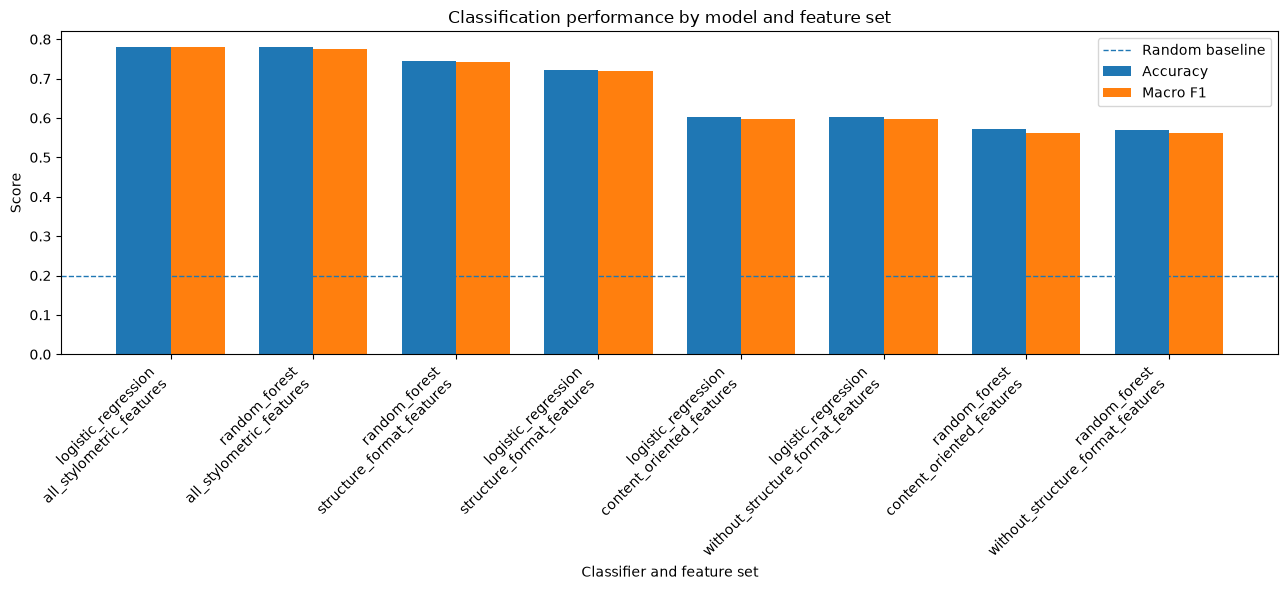

In [4]:
plot_df = performance_sorted.copy()
plot_df["model_feature_set"] = (
    plot_df["model_name"] + "\n" + plot_df["feature_set"]
)

x_labels = plot_df["model_feature_set"].astype(str).tolist()
accuracy_values = plot_df["accuracy"].astype(float).to_numpy()
macro_f1_values = plot_df["macro_f1"].astype(float).to_numpy()

x_positions = np.arange(len(x_labels))
bar_width = 0.38

plt.figure(figsize=(13, 6))
plt.bar(x_positions - bar_width / 2, accuracy_values, width=bar_width, label="Accuracy")
plt.bar(x_positions + bar_width / 2, macro_f1_values, width=bar_width, label="Macro F1")
plt.axhline(0.20, linestyle="--", linewidth=1, label="Random baseline")
plt.xticks(x_positions, x_labels, rotation=45, ha="right")
plt.ylabel("Score")
plt.xlabel("Classifier and feature set")
plt.title("Classification performance by model and feature set")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "classification_model_performance.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of the performance chart

This chart compares **accuracy** and **macro F1** for every classifier-feature-set combination. The dashed horizontal line marks the **20% random baseline** for five balanced model classes.

The chart shows three clear patterns.

First, the two tallest bars are the models trained on **all stylometric features**. Logistic Regression reaches **0.781 accuracy**, while Random Forest reaches **0.779 accuracy**. Their macro F1 scores are almost identical to their accuracies, which is expected because the dataset is balanced across the five model families.

Second, the **structure/format feature set** is the next strongest group. Random Forest reaches **0.745 accuracy**, and Logistic Regression reaches **0.722 accuracy**. These bars are much closer to the full-feature models than to the content-only models, which means structural features carry a large part of the model-identification signal.

Third, the **content-oriented** and **without-structure/format** feature sets are lower, around **0.57–0.60 accuracy**, but still well above the 20% baseline. This shows that lexical and discourse features contain some model-family information, but they are less powerful than structural and punctuation-based stylometry.

Overall, the chart supports the conclusion that model-family fingerprints are strongest when all stylometric dimensions are combined, especially structural and formatting-related features.

In [5]:
feature_set_summary = (
    performance_df.groupby("feature_set")
    .agg(
        best_accuracy=("accuracy", "max"),
        mean_accuracy=("accuracy", "mean"),
        best_macro_f1=("macro_f1", "max"),
        mean_macro_f1=("macro_f1", "mean"),
        n_models=("model_name", "count"),
        n_features=("n_features", "first"),
    )
    .sort_values("best_macro_f1", ascending=False)
    .reset_index()
)

display(feature_set_summary)

,feature_set,best_accuracy,mean_accuracy,best_macro_f1,mean_macro_f1,n_models,n_features
0,all_stylometric_features,0.781,0.7800,0.780435,0.778329,2,43
1,structure_format_features,0.745,0.7335,0.741636,0.730629,2,26
2,content_oriented_features,0.602,0.5865,0.598601,0.580369,2,17
3,without_structure_format_features,0.602,0.5855,0.598601,0.579691,2,17


### Interpretation of feature-set comparison

The feature-set summary confirms the same ranking seen in the performance chart.

The **all-stylometric-features** set is the strongest, with a best accuracy of **0.781** and a best macro F1 of **0.780**. This means the best prediction comes from combining all feature families: length, sentence structure, punctuation, casing, lexical diversity, discourse markers, function words, and readability.

The **structure/format** feature set is second strongest, with a best accuracy of **0.745** and a best macro F1 of **0.742**. This is a major project finding because it means surface-level writing structure alone can identify model family with high accuracy.

The **content-oriented** and **without-structure/format** feature sets perform similarly because they contain the same 17 features in the current implementation. Their best accuracy is **0.602**, which is still three times higher than chance, but clearly below the structure/format models.

As the data scientist conducting this analysis, I interpret this result as evidence that LLM fingerprinting is driven more by *how* models write than by the semantic content of what they write.

## 3. Confusion matrix analysis

Next, I inspect confusion matrices for the best-performing models. The confusion matrix shows which model families are predicted correctly and which model families are confused with each other.

Rows represent the true model family. Columns represent the predicted model family.

In [6]:
def load_confusion_matrix(classifier_name: str, feature_set: str) -> pd.DataFrame:
    path = CLASSIFICATION_DIR / f"confusion_matrix_{classifier_name}_{feature_set}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Confusion matrix not found: {path}")

    return pd.read_csv(path, index_col=0)


conf_lr_all = load_confusion_matrix(
    "logistic_regression",
    "all_stylometric_features",
)

conf_rf_all = load_confusion_matrix(
    "random_forest",
    "all_stylometric_features",
)

display(conf_lr_all)
display(conf_rf_all)

,pred_Claude,pred_DeepSeek,pred_GPT,pred_Gemini,pred_Mistral
true_Claude,181,0,6,3,10
true_DeepSeek,3,168,10,9,10
true_GPT,4,7,148,20,21
true_Gemini,2,12,14,149,23
true_Mistral,13,22,15,15,135


,pred_Claude,pred_DeepSeek,pred_GPT,pred_Gemini,pred_Mistral
true_Claude,177,2,10,1,10
true_DeepSeek,1,172,6,12,9
true_GPT,9,5,156,21,9
true_Gemini,3,14,14,154,15
true_Mistral,16,27,19,18,120


### Interpretation of confusion matrices

The confusion matrices show how the two best models classify each model family when all stylometric features are used. Rows are the true model families, and columns are the predicted model families.

For **Logistic Regression**, the correct predictions on the diagonal are:

- Claude: **181/200**
- DeepSeek: **168/200**
- GPT: **148/200**
- Gemini: **149/200**
- Mistral: **135/200**

Claude is the easiest model for Logistic Regression to identify, while Mistral is the hardest. The largest errors involve Mistral being confused with DeepSeek, GPT, Gemini, and Claude. GPT and Gemini also show some mutual confusion, with GPT predicted as Gemini 20 times and Gemini predicted as Mistral 23 times.

For **Random Forest**, the correct predictions are:

- Claude: **177/200**
- DeepSeek: **172/200**
- GPT: **156/200**
- Gemini: **154/200**
- Mistral: **120/200**

Random Forest improves DeepSeek, GPT, and Gemini recall slightly compared with Logistic Regression, but it performs worse on Mistral. Mistral is frequently predicted as DeepSeek, GPT, Gemini, or Claude.

Overall, both confusion matrices show strong diagonal dominance, meaning that most predictions are correct. The off-diagonal errors are analytically useful because they show which model families are stylometrically closer to each other.

In [7]:
def plot_confusion_matrix_df(
    matrix_df: pd.DataFrame,
    title: str,
    output_filename: str,
) -> None:
    matrix_values = matrix_df.to_numpy(dtype=float)
    x_labels = [label.replace("pred_", "") for label in matrix_df.columns.astype(str)]
    y_labels = [label.replace("true_", "") for label in matrix_df.index.astype(str)]

    plt.figure(figsize=(7, 6))
    plt.imshow(matrix_values)
    plt.colorbar(label="Number of texts")

    plt.xticks(np.arange(len(x_labels)), x_labels, rotation=45, ha="right")
    plt.yticks(np.arange(len(y_labels)), y_labels)

    for row_idx in range(matrix_values.shape[0]):
        for col_idx in range(matrix_values.shape[1]):
            plt.text(
                col_idx,
                row_idx,
                str(int(matrix_values[row_idx, col_idx])),
                ha="center",
                va="center",
            )

    plt.xlabel("Predicted model family")
    plt.ylabel("True model family")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / output_filename, dpi=300, bbox_inches="tight")
    plt.show()

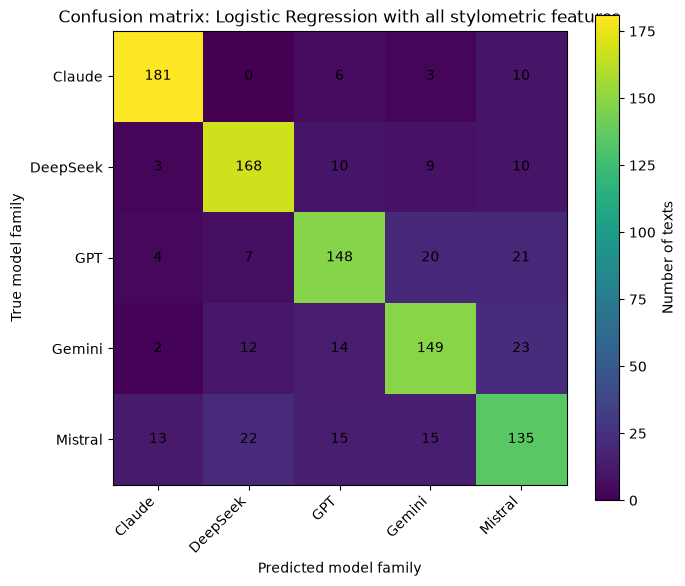

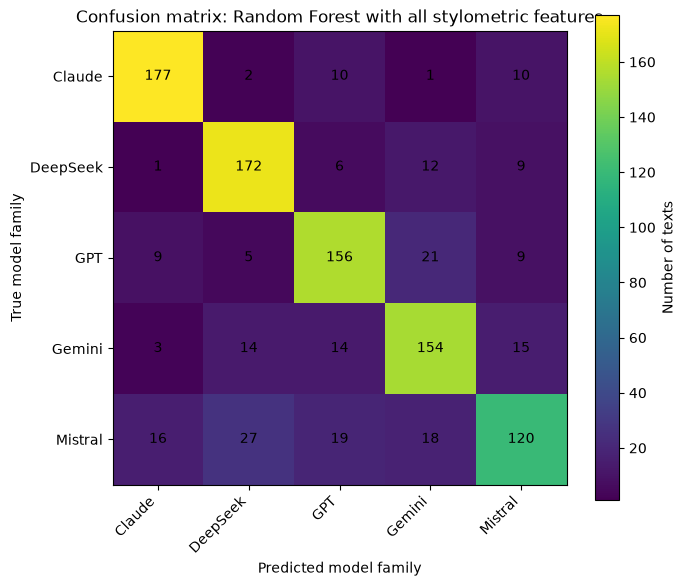

In [8]:
plot_confusion_matrix_df(
    matrix_df=conf_lr_all,
    title="Confusion matrix: Logistic Regression with all stylometric features",
    output_filename="classification_confusion_matrix_logistic_regression_all_features.png",
)

plot_confusion_matrix_df(
    matrix_df=conf_rf_all,
    title="Confusion matrix: Random Forest with all stylometric features",
    output_filename="classification_confusion_matrix_random_forest_all_features.png",
)

### Interpretation of confusion matrix charts

The confusion matrix charts visually confirm the same pattern as the tables. The darkest or largest-count cells are mostly on the diagonal, showing that both classifiers frequently recover the correct model family from stylometric features alone.

The **Logistic Regression** chart shows especially strong recognition of Claude, with 181 correct Claude predictions. It also performs well on DeepSeek. The weakest diagonal cell is Mistral, with 135 correct predictions. This means Mistral has the least distinctive stylometric profile for the linear classifier.

The **Random Forest** chart also has a strong diagonal, but the Mistral diagonal cell is lower at 120 correct predictions. Random Forest identifies DeepSeek, GPT, and Gemini slightly better than Logistic Regression, but it confuses Mistral more often, especially with DeepSeek.

These charts show that classification errors are not random. They cluster around specific model pairs, suggesting that some model families are more stylistically similar in the extracted feature space.

## 4. Random-forest feature importance

After evaluating predictive performance with prompt-aware cross-validation, I inspect Random Forest feature importance using all stylometric features.

This interpretation is exploratory. The feature-importance model is fitted on the full dataset after cross-validation. Therefore, I use it to understand which features may drive classification, not to estimate predictive performance.

In [9]:
display(rf_importance_df.head(20))

,feature,importance
0,stylo_word_count,0.075832
1,stylo_avg_word_length,0.041416
2,stylo_character_count,0.041354
3,stylo_sentence_length_std,0.039381
4,stylo_comma_per_100_words,0.037727
5,stylo_punctuation_per_100_words,0.037499
6,stylo_function_word_count,0.035403
7,stylo_type_token_ratio,0.034445
8,stylo_long_sentence_ratio,0.034249
9,stylo_comma_count,0.032765


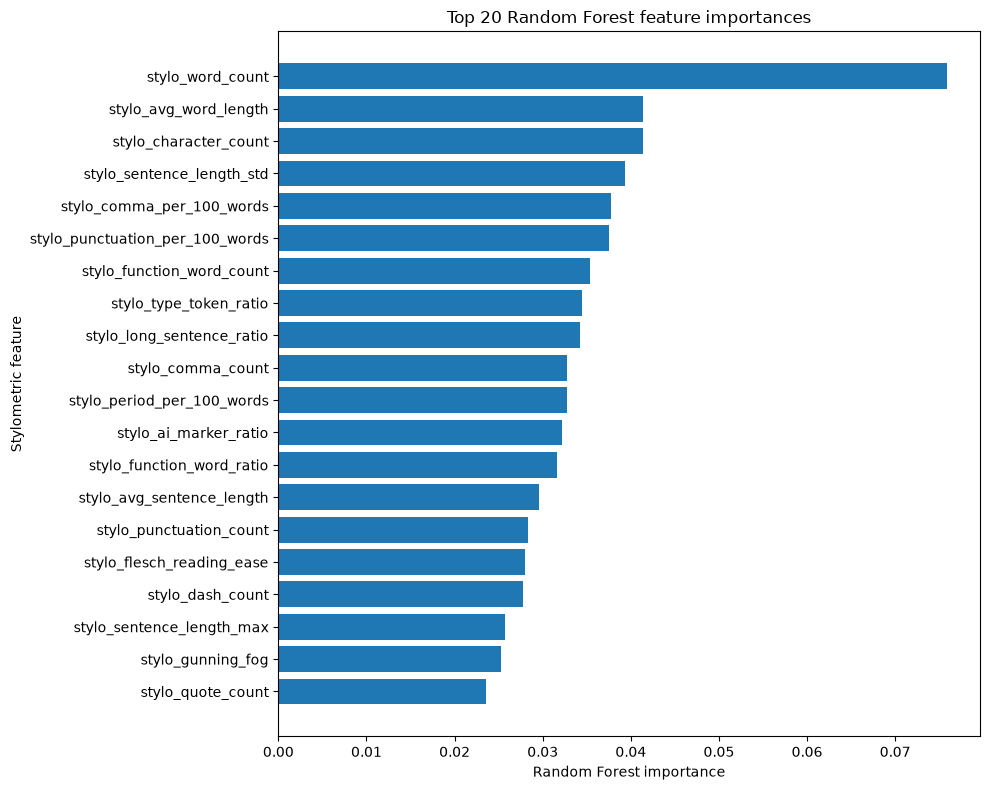

In [10]:
top_importance = rf_importance_df.head(20).copy()

x_values = top_importance["importance"].astype(float).to_numpy()
y_labels = top_importance["feature"].astype(str).tolist()

plt.figure(figsize=(10, 8))
plt.barh(y_labels[::-1], x_values[::-1])
plt.xlabel("Random Forest importance")
plt.ylabel("Stylometric feature")
plt.title("Top 20 Random Forest feature importances")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "classification_random_forest_top_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Random Forest feature importance

The Random Forest feature-importance table and chart show which individual stylometric variables contribute most to model-family prediction.

The most important feature is:

- `stylo_word_count`: **0.0758**

This means that even under the controlled word-limit design, small differences in final word count remain highly predictive of model family.

The next most important features are:

- `stylo_avg_word_length`: **0.0414**
- `stylo_character_count`: **0.0414**
- `stylo_sentence_length_std`: **0.0394**
- `stylo_comma_per_100_words`: **0.0377**
- `stylo_punctuation_per_100_words`: **0.0375**
- `stylo_function_word_count`: **0.0354**
- `stylo_type_token_ratio`: **0.0344**
- `stylo_long_sentence_ratio`: **0.0342**

The chart shows that the strongest predictors are not a single type of feature. They include length, word shape, sentence variability, punctuation density, function-word usage, lexical diversity, and long-sentence behavior.

This is consistent with the statistical-testing phase. The same kinds of features that showed large Kruskal-Wallis effects also appear as important predictive variables in the Random Forest model.

Therefore, I interpret the feature-importance results as evidence that model-family fingerprints are distributed across several stylometric dimensions rather than depending on one isolated marker.

## 5. Feature-family importance

Individual feature importance is useful, but I also want to know which broader families of features are most predictive.

The feature-family summary groups features into categories such as:

- length and sentence structure;
- punctuation;
- casing;
- lexical diversity;
- markers and function words;
- readability.

In [11]:
display(feature_family_df)

,feature_family,total_importance,mean_importance,n_features
0,length_structure,0.409051,0.029218,14
1,punctuation,0.260756,0.021730,12
2,lexical_diversity,0.142951,0.020422,7
3,markers_function_words,0.118956,0.016994,7
4,readability,0.053283,0.026641,2
5,casing,0.015004,0.015004,1


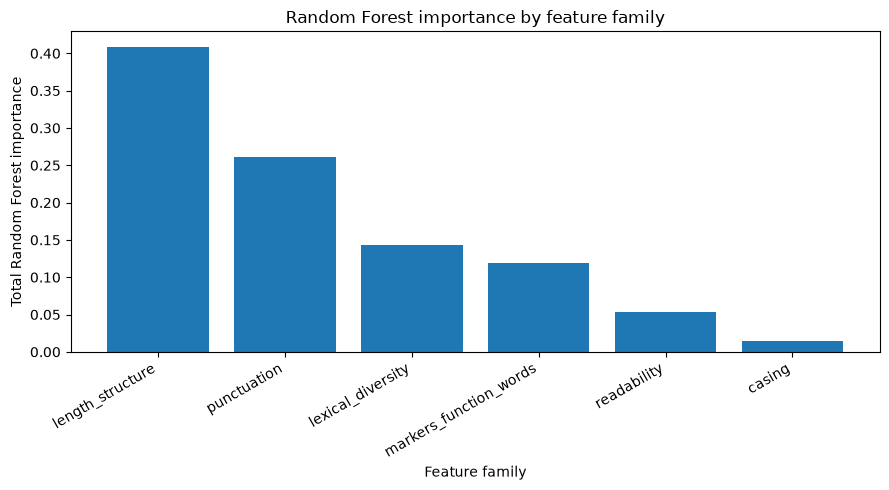

In [12]:
family_plot_df = feature_family_df.sort_values("total_importance", ascending=False).copy()

x_labels = family_plot_df["feature_family"].astype(str).tolist()
y_values = family_plot_df["total_importance"].astype(float).to_numpy()

plt.figure(figsize=(9, 5))
plt.bar(x_labels, y_values)
plt.xlabel("Feature family")
plt.ylabel("Total Random Forest importance")
plt.title("Random Forest importance by feature family")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "classification_feature_family_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of feature-family importance chart

The feature-family importance chart aggregates Random Forest importance by broader stylometric category.

The highest-ranked feature family is:

- **length_structure**: total importance **0.409**

This means that sentence length, word count, character count, and sentence-structure variation are the strongest family-level predictors of model identity.

The second highest-ranked family is:

- **punctuation**: total importance **0.261**

This confirms that punctuation behavior, including comma use, period density, dash use, and quote use, is a major source of model-family signal.

The remaining families contribute less but still add useful information:

- **lexical_diversity**: **0.143**
- **markers_function_words**: **0.119**
- **readability**: **0.053**
- **casing**: **0.015**

This chart strongly supports one of my central findings: LLM model identity is most visible in structural and punctuation-based stylometry. Lexical diversity and discourse markers add additional signal, but they are secondary to structure and punctuation.

## 6. Classification reports

The classification reports provide per-class precision, recall, and F1-score for the best model. These metrics show whether some model families are easier or harder to identify.

In [13]:
def load_classification_report(classifier_name: str, feature_set: str) -> pd.DataFrame:
    path = CLASSIFICATION_DIR / f"classification_report_{classifier_name}_{feature_set}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Classification report not found: {path}")

    return pd.read_csv(path, index_col=0)


report_lr_all = load_classification_report(
    "logistic_regression",
    "all_stylometric_features",
)

report_rf_all = load_classification_report(
    "random_forest",
    "all_stylometric_features",
)

display(report_lr_all)
display(report_rf_all)

,precision,recall,f1-score,support
Claude,0.891626,0.905,0.898263,200.000
DeepSeek,0.803828,0.840,0.821516,200.000
GPT,0.766839,0.740,0.753181,200.000
Gemini,0.760204,0.745,0.752525,200.000
Mistral,0.678392,0.675,0.676692,200.000
accuracy,0.781000,0.781,0.781000,0.781
macro avg,0.780178,0.781,0.780435,1000.000
weighted avg,0.780178,0.781,0.780435,1000.000


,precision,recall,f1-score,support
Claude,0.859223,0.885,0.871921,200.000
DeepSeek,0.781818,0.860,0.819048,200.000
GPT,0.760976,0.780,0.770370,200.000
Gemini,0.747573,0.770,0.758621,200.000
Mistral,0.736196,0.600,0.661157,200.000
accuracy,0.779000,0.779,0.779000,0.779
macro avg,0.777157,0.779,0.776223,1000.000
weighted avg,0.777157,0.779,0.776223,1000.000


### Interpretation of classification reports

The classification reports provide per-class precision, recall, and F1-score for the two best models.

For **Logistic Regression with all stylometric features**:

- Claude has the strongest performance, with **0.905 recall** and **0.898 F1**.
- DeepSeek is also well identified, with **0.840 recall** and **0.822 F1**.
- GPT and Gemini are moderately strong, with F1 scores around **0.753**.
- Mistral is the weakest class, with **0.675 recall** and **0.677 F1**.

For **Random Forest with all stylometric features**:

- Claude again performs strongly, with **0.885 recall** and **0.872 F1**.
- DeepSeek has the highest recall among Random Forest classes, at **0.860**.
- GPT and Gemini improve slightly compared with Logistic Regression in recall.
- Mistral remains the weakest class, with only **0.600 recall** and **0.661 F1**.

These reports show that the models are not equally easy to identify. Claude and DeepSeek have more distinctive stylometric profiles, while Mistral is more often confused with other model families.

This is important because it shows that the classification task is not simply separating all models equally. Instead, the results reveal a hierarchy of stylometric distinctiveness across model families.

In [14]:
performance_sorted.to_csv(TABLE_DIR / "notebook_08_classification_performance_summary.csv", index=False)
feature_set_summary.to_csv(TABLE_DIR / "notebook_08_feature_set_summary.csv", index=False)
rf_importance_df.to_csv(TABLE_DIR / "notebook_08_random_forest_feature_importance.csv", index=False)
feature_family_df.to_csv(TABLE_DIR / "notebook_08_feature_family_importance.csv", index=False)

print("Saved notebook classification summary tables to:", TABLE_DIR)

Saved notebook classification summary tables to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/tables


## 7. Classification conclusion

The classification results provide strong evidence that stylometric features can predict which LLM family generated a text.

Using all 43 stylometric features, **Logistic Regression reaches 78.1% accuracy and 0.780 macro F1**. Random Forest performs almost identically, with **77.9% accuracy and 0.776 macro F1**. Since the dataset has five balanced model families, the random baseline is only **20%**. The best classifiers therefore perform almost four times above chance.

The feature-set comparison shows that the strongest results come from combining all stylometric features. However, structure/format features alone are also highly predictive, reaching up to **74.5% accuracy**. This indicates that model identity is especially visible in sentence structure, punctuation, word count, character density, casing, and related formal writing properties.

The confusion matrices show that Claude and DeepSeek are generally easier to identify, while Mistral is the hardest model family to classify. This suggests that some LLM families have more distinctive stylometric profiles than others.

The Random Forest feature-importance results show that the strongest individual predictors include word count, average word length, character count, sentence-length variation, comma density, punctuation density, function-word count, type-token ratio, and long-sentence ratio. At the feature-family level, length/structure and punctuation dominate the prediction signal.

Because this experiment uses prompt-aware GroupKFold cross-validation, the same prompts are not shared between training and testing folds. This reduces the risk that the classifier is simply learning prompt content. Instead, the results support the central claim of the project: LLM-generated texts contain measurable model-specific writing-style fingerprints that can be used to predict the generating model family.